# Spread Estimation from Market Data

**Docker image**: `ml4t`

This notebook estimates relative bid-ask spreads from OHLCV data, checks their level against a
regular-session NASDAQ-100 quoted-spread benchmark, and audits whether case-study cost inputs are
dimensionally comparable.

**Learning Objectives:**
- Implement the Corwin-Schultz (2012) high-low spread estimator
- Implement the Roll (1984) serial-covariance spread estimator in relative-return units
- Compare both estimators with a regular-session quoted-spread benchmark
- Build a frequency-aligned descriptive map across six liquid market samples
- Separate spread estimates from fees, all-in costs, ticks, and dollar-per-share inputs

**Book Reference:** Chapter 18, Section 18.3 (The Microstructure-Regime Link)

**Prerequisites:** Access to six OHLCV datasets and licensed NASDAQ-100 minute bars with
microstructure columns.

In [1]:
"""Spread estimation from market data with unit-aware validation."""

import logging
import warnings

warnings.filterwarnings("ignore")
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import yaml
from _cost_analysis import corwin_schultz_spread, roll_spread
from IPython.display import Markdown, display

from data import (
    load_cme_futures,
    load_crypto_perps,
    load_etfs,
    load_fx_pairs,
    load_macro,
    load_nasdaq100_bars,
    load_sp500_daily_bars,
)
from utils.paths import get_case_study_source_dir
from utils.style import COLORS, FIGSIZE, add_message_title

In [2]:
MAX_SYMBOLS = 50
NQ100_SYMBOLS = 12
NQ100_START_DATE = "2021-10-01"
NQ100_END_DATE = "2021-12-31"
CS_WINDOW = 20
ROLL_WINDOW = 20

## 1. Two OHLCV Estimators

The Corwin-Schultz estimator separates the two-day high-low range into volatility and spread
components. For consecutive periods,

$$
\beta = \mathbb{E}\left[\sum_{j=1}^{2}
\ln\left(\frac{H_j}{L_j}\right)^2\right], \qquad
\gamma = \mathbb{E}\left[
\ln\left(\frac{H_{[1,2]}}{L_{[1,2]}}\right)^2\right].
$$

The spread estimate follows from

$$
\alpha = \frac{\sqrt{2\beta}-\sqrt{\beta}}{3-2\sqrt{2}}
-\sqrt{\frac{\gamma}{3-2\sqrt{2}}}, \qquad
\widehat{S}_{CS}=\frac{2(e^\alpha-1)}{1+e^\alpha}.
$$

Negative estimates are clamped to zero when the high-low range is dominated by volatility.
Corwin and Schultz (2012) provide the derivation and empirical validation:
<https://doi.org/10.1111/j.1540-6261.2012.01729.x>.

Roll's estimator attributes negative first-order return covariance to bid-ask bounce. The shared
implementation uses percentage returns, so its output is a relative spread:

$$
r_t=\frac{P_t}{P_{t-1}}-1, \qquad
\widehat{S}_{Roll}=2\sqrt{-\operatorname{Cov}(r_t,r_{t-1})}.
$$

Positive covariance produces a zero estimate. Roll (1984) states the market assumptions behind
this measure: <https://doi.org/10.1111/j.1540-6261.1984.tb03897.x>.

## 2. A Regular-Session Quote Benchmark

Raw AlgoSeek microstructure mode intentionally bypasses the loader's regular-hours filter. The
function below restores the documented 09:30-16:00 ET window before any symbol selection or daily
aggregation. It keeps the trade panel separate from the valid-quote panel so a bad quote cannot
remove a legitimate daily high or low.

In [3]:
def load_nq_microstructure() -> tuple[pl.LazyFrame, pl.LazyFrame, pl.LazyFrame]:
    """Load raw, regular-session, and valid-quote NASDAQ-100 minute panels."""
    raw = load_nasdaq100_bars(
        start_date=NQ100_START_DATE,
        end_date=NQ100_END_DATE,
        include_microstructure=True,
        lazy=True,
    ).select(
        "timestamp",
        "symbol",
        "volume",
        "close_bid_price",
        "close_ask_price",
        "high_trade_price",
        "low_trade_price",
        "first_trade_price",
        "last_trade_price",
    )
    hour = pl.col("timestamp").dt.hour()
    minute = pl.col("timestamp").dt.minute()
    regular = raw.filter(((hour > 9) | ((hour == 9) & (minute >= 30))) & (hour < 16))
    valid_quotes = (
        regular.filter(
            pl.col("close_bid_price").is_not_null()
            & pl.col("close_ask_price").is_not_null()
            & (pl.col("close_bid_price") > 0)
            & (pl.col("close_ask_price") > pl.col("close_bid_price"))
            & (pl.col("volume").fill_null(0) > 0)
        )
        .with_columns(
            midpoint=(pl.col("close_bid_price") + pl.col("close_ask_price")) / 2,
            quoted_spread=pl.col("close_ask_price") - pl.col("close_bid_price"),
        )
        .with_columns(quoted_spread_rel=pl.col("quoted_spread") / pl.col("midpoint"))
    )
    return raw, regular, valid_quotes

### Select a Descriptive Liquid Sample

The full-window volume ranking is a tractability choice, not a point-in-time universe. Every
result below therefore describes a liquid late-2021 sample rather than the full NASDAQ-100.

In [4]:
raw_nq_lf, regular_nq_lf, quote_nq_lf = load_nq_microstructure()

if NQ100_SYMBOLS > 0:
    top_symbols = (
        regular_nq_lf.group_by("symbol")
        .agg(pl.col("volume").sum())
        .sort("volume", descending=True)
        .head(NQ100_SYMBOLS)
        .collect()["symbol"]
        .to_list()
    )
    raw_nq_lf = raw_nq_lf.filter(pl.col("symbol").is_in(top_symbols))
    regular_nq_lf = regular_nq_lf.filter(pl.col("symbol").is_in(top_symbols))
    quote_nq_lf = quote_nq_lf.filter(pl.col("symbol").is_in(top_symbols))

### Reconcile Session and Quote Filters

The conservation table makes the benchmark population explicit. Locked, crossed, null, zero, and
zero-volume quote rows remain accounted exclusions rather than disappearing silently.

In [5]:
raw_rows = raw_nq_lf.select(pl.len()).collect().item()
regular_rows = regular_nq_lf.select(pl.len()).collect().item()
valid_quote_rows = quote_nq_lf.select(pl.len()).collect().item()
regular_keys = regular_nq_lf.select(pl.struct("symbol", "timestamp").n_unique()).collect().item()

quote_integrity = pl.DataFrame(
    {
        "population": [
            "Selected raw minutes",
            "Outside regular session",
            "Regular-session minutes",
            "Invalid/locked/zero-volume quotes",
            "Valid quote minutes",
            "Duplicate keys",
        ],
        "rows": [
            raw_rows,
            raw_rows - regular_rows,
            regular_rows,
            regular_rows - valid_quote_rows,
            valid_quote_rows,
            regular_rows - regular_keys,
        ],
    }
)
quote_integrity

population,rows
str,i64
"""Selected raw minutes""",734206
"""Outside regular session""",434686
"""Regular-session minutes""",299520
"""Invalid/locked/zero-volume quo…",586
"""Valid quote minutes""",298934
"""Duplicate keys""",0


### Aggregate Trades and Quotes Independently

Daily OHLCV uses every valid regular-session trade bar. The benchmark uses only valid minute-close
quotes and weights their relative spreads by contemporaneous trade volume. Their inner join is the
comparison sample.

In [6]:
nq_trade_daily = (
    regular_nq_lf.filter(
        pl.col("high_trade_price").is_not_null()
        & pl.col("low_trade_price").is_not_null()
        & (pl.col("low_trade_price") > 0)
    )
    .with_columns(date=pl.col("timestamp").dt.date())
    .sort(["symbol", "timestamp"])
    .group_by(["date", "symbol"])
    .agg(
        high=pl.col("high_trade_price").max(),
        low=pl.col("low_trade_price").min(),
        open=pl.col("first_trade_price").drop_nulls().first(),
        close=pl.col("last_trade_price").drop_nulls().last(),
        volume=pl.col("volume").fill_null(0).sum(),
    )
    .filter(
        pl.col("open").is_not_null()
        & pl.col("close").is_not_null()
        & (pl.col("high") > pl.col("low"))
    )
    .collect()
)

In [7]:
nq_quote_daily = (
    quote_nq_lf.with_columns(date=pl.col("timestamp").dt.date())
    .group_by(["date", "symbol"])
    .agg(
        quoted_close_spread=(
            (pl.col("quoted_spread_rel") * pl.col("volume")).sum() / pl.col("volume").sum()
        ),
        quote_minutes=pl.len(),
    )
    .collect()
)

nq_daily = nq_trade_daily.join(nq_quote_daily, on=["date", "symbol"], how="inner").sort(
    ["symbol", "date"]
)
if nq_daily.is_empty():
    raise ValueError("No regular-session NASDAQ-100 symbol-days remain after quote validation.")

median_quote_bps = nq_daily["quoted_close_spread"].median() * 10_000
display(
    Markdown(
        f"The benchmark contains **{len(nq_daily):,} symbol-days** across "
        f"**{nq_daily['symbol'].n_unique()} symbols**. Its median volume-weighted minute-close "
        f"quoted spread is **{median_quote_bps:.1f} bps**."
    )
)

The benchmark contains **768 symbol-days** across **12 symbols**. Its median volume-weighted minute-close quoted spread is **2.1 bps**.

## 3. Symbol-Isolated Estimation

Each shift and rolling window must restart at a symbol boundary. Wrapping the complete estimator
expression with `over("symbol")` prevents one asset's final rows from seeding the next asset.

In [8]:
def estimate_spreads(df: pl.DataFrame) -> pl.DataFrame:
    """Add symbol-isolated Corwin-Schultz and Roll relative-spread estimates."""
    return df.sort(["symbol", "timestamp"]).with_columns(
        cs_spread=corwin_schultz_spread(pl.col("high"), pl.col("low"), window=CS_WINDOW).over(
            "symbol"
        ),
        roll_spread_est=roll_spread(pl.col("close"), window=ROLL_WINDOW).over("symbol"),
    )

In [9]:
nq_estimator_input = nq_daily.select(
    pl.col("date").cast(pl.Datetime).alias("timestamp"),
    "symbol",
    "open",
    "high",
    "low",
    "close",
    "volume",
    "quoted_close_spread",
)
nq_estimated = estimate_spreads(nq_estimator_input).filter(
    pl.col("cs_spread").is_not_null()
    & pl.col("roll_spread_est").is_not_null()
    & pl.col("quoted_close_spread").is_not_null()
)
if nq_estimated.is_empty():
    raise ValueError("The configured windows leave no matched NASDAQ-100 observations.")

nq_validation = (
    nq_estimated.group_by("symbol")
    .agg(
        quoted_bps=pl.col("quoted_close_spread").median() * 10_000,
        cs_bps=pl.col("cs_spread").median() * 10_000,
        roll_bps=pl.col("roll_spread_est").median() * 10_000,
    )
    .sort("quoted_bps")
)
if len(nq_validation) < 2:
    raise ValueError("At least two symbols are required for validation metrics.")

### Measure Association and Level Accuracy Separately

Pearson correlation measures linear association. MAE and signed bias measure calibration to the
quoted-spread level. The identity-line coefficient of determination,
$1-\sum(y-\hat y)^2/\sum(y-\bar y)^2$, can be negative when an estimator is worse than predicting
the benchmark mean. It is not the squared correlation.

In [10]:
def compute_validation_metrics(validation: pl.DataFrame) -> pl.DataFrame:
    """Compute association and identity-line accuracy for both estimators."""
    observed = validation["quoted_bps"].to_numpy()
    rows = []
    for column, estimator in (("cs_bps", "Corwin-Schultz"), ("roll_bps", "Roll")):
        estimated = validation[column].to_numpy()
        mask = np.isfinite(observed) & np.isfinite(estimated)
        y, y_hat = observed[mask], estimated[mask]
        sst = np.sum((y - y.mean()) ** 2)
        rows.append(
            {
                "estimator": estimator,
                "pearson_r": np.corrcoef(y, y_hat)[0, 1],
                "identity_r2": 1 - np.sum((y - y_hat) ** 2) / sst,
                "mae_bps": np.mean(np.abs(y - y_hat)),
                "bias_bps": np.mean(y_hat - y),
            }
        )
    return pl.DataFrame(rows)

In [11]:
validation_metrics = compute_validation_metrics(nq_validation)
metric_rows = {row["estimator"]: row for row in validation_metrics.to_dicts()}
cs_metrics = metric_rows["Corwin-Schultz"]
roll_metrics = metric_rows["Roll"]

display(
    Markdown(
        f"Across **{len(nq_estimated):,} matched symbol-days**, Corwin-Schultz has Pearson "
        f"$r={cs_metrics['pearson_r']:.2f}$, MAE **{cs_metrics['mae_bps']:.1f} bps**, and bias "
        f"**{cs_metrics['bias_bps']:+.1f} bps**. Roll has $r={roll_metrics['pearson_r']:.2f}$, "
        f"MAE **{roll_metrics['mae_bps']:.1f} bps**, and bias "
        f"**{roll_metrics['bias_bps']:+.1f} bps**. Their identity-line $R^2$ values are "
        f"**{cs_metrics['identity_r2']:.1f}** and **{roll_metrics['identity_r2']:.1f}**, "
        "respectively, which makes poor level calibration visible."
    )
)

Across **516 matched symbol-days**, Corwin-Schultz has Pearson $r=-0.28$, MAE **13.8 bps**, and bias **+7.6 bps**. Roll has $r=-0.01$, MAE **117.3 bps**, and bias **+115.6 bps**. Their identity-line $R^2$ values are **-32.1** and **-1781.9**, respectively, which makes poor level calibration visible.

### Estimated Versus Quoted Spreads

The 45-degree line is the calibration target. Shared limits keep the two estimators comparable.

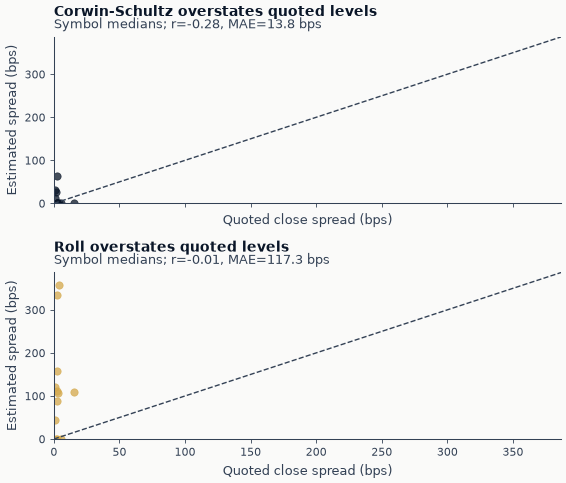

In [12]:
fig, axes = plt.subplots(2, 1, figsize=FIGSIZE["dual_v"], sharex=True, sharey=True)
plot_specs = (
    (axes[0], "cs_bps", "Corwin-Schultz", COLORS["blue"]),
    (axes[1], "roll_bps", "Roll", COLORS["amber"]),
)
limit = 1.08 * max(
    nq_validation["quoted_bps"].max(),
    nq_validation["cs_bps"].max(),
    nq_validation["roll_bps"].max(),
)

for ax, column, estimator, color in plot_specs:
    metrics = metric_rows[estimator]
    ax.scatter(
        nq_validation["quoted_bps"],
        nq_validation[column],
        color=color,
        alpha=0.75,
        s=28,
    )
    ax.plot([0, limit], [0, limit], color=COLORS["neutral"], linestyle="--", linewidth=1)
    ax.set_xlim(0, limit)
    ax.set_ylim(0, limit)
    ax.set_xlabel("Quoted close spread (bps)")
    ax.set_ylabel("Estimated spread (bps)")
    direction = "overstates" if metrics["bias_bps"] > 0 else "understates"
    add_message_title(
        ax,
        f"{estimator} {direction} quoted levels",
        subtitle=f"Symbol medians; r={metrics['pearson_r']:.2f}, MAE={metrics['mae_bps']:.1f} bps",
    )

fig.tight_layout()
fig.show()

The benchmark is a volume-weighted minute-close quoted spread, not an effective or realized
execution spread. The comparison diagnoses estimator resolution on this sample; it does not prove
how either estimator performs in markets without quotes.

## 4. A Frequency-Aligned Cross-Asset Map

The comparison uses daily bars throughout. Crypto's funding-aligned 8-hour bars are aggregated to
UTC calendar days before a 20-row window is applied. Liquid-symbol selection remains full-sample
and descriptive.

In [13]:
def keep_top_symbols(df: pl.DataFrame, symbol_col: str) -> pl.DataFrame:
    """Restrict a volume-bearing panel to a full-sample liquid subset."""
    if MAX_SYMBOLS <= 0:
        return df
    top = (
        df.group_by(symbol_col)
        .agg(pl.col("volume").mean())
        .sort("volume", descending=True)
        .head(MAX_SYMBOLS)[symbol_col]
    )
    return df.filter(pl.col(symbol_col).is_in(top))

Crypto trades continuously, so UTC calendar days provide a transparent, reproducible daily
convention. OHLC uses first/max/min/last and volume sums across the three 8-hour bars.

In [14]:
def aggregate_crypto_daily(df: pl.DataFrame) -> pl.DataFrame:
    """Aggregate funding-aligned crypto bars to UTC calendar-day OHLCV."""
    return (
        df.with_columns(day=pl.col("timestamp").dt.date())
        .sort(["symbol", "timestamp"])
        .group_by(["symbol", "day"])
        .agg(
            open=pl.col("open").first(),
            high=pl.col("high").max(),
            low=pl.col("low").min(),
            close=pl.col("close").last(),
            volume=pl.col("volume").sum(),
        )
        .rename({"day": "timestamp"})
        .with_columns(pl.col("timestamp").cast(pl.Datetime))
        .sort(["symbol", "timestamp"])
    )

### Assemble the Six Panels

CME uses roll-adjusted OHLC. The adjustment is multiplicative, so it cancels from each same-day
high-low ratio and prevents contract-roll jumps from entering Roll returns. Raw contract volume is
used only for liquidity selection.

In [15]:
datasets: dict[str, pl.DataFrame] = {}
datasets["ETFs"] = keep_top_symbols(load_etfs(), "symbol")

crypto_8h = keep_top_symbols(load_crypto_perps(frequency="8h"), "symbol")
datasets["Crypto Perps"] = aggregate_crypto_daily(crypto_8h)

datasets["CME Futures"] = (
    keep_top_symbols(load_cme_futures(tenors=[0]), "product")
    .rename({"session_date": "timestamp", "product": "symbol"})
    .with_columns(
        pl.col("adj_open").alias("open"),
        pl.col("adj_high").alias("high"),
        pl.col("adj_low").alias("low"),
        pl.col("adj_close").alias("close"),
    )
    .select("timestamp", "symbol", "open", "high", "low", "close", "volume")
)

In [16]:
fx = load_fx_pairs(frequency="daily")
if MAX_SYMBOLS > 0:
    fx_symbols = fx["symbol"].unique().sort().head(MAX_SYMBOLS)
    fx = fx.filter(pl.col("symbol").is_in(fx_symbols))
datasets["FX Pairs"] = fx

sp500 = load_sp500_daily_bars()
if "timestamp" not in sp500.columns:
    raise ValueError("S&P 500 loader must provide canonical timestamp keys.")
datasets["S&P 500 Equities"] = keep_top_symbols(sp500, "symbol").select(
    "timestamp", "symbol", "open", "high", "low", "close", "volume"
)

datasets["NASDAQ-100"] = nq_estimator_input.select(
    "timestamp", "symbol", "open", "high", "low", "close", "volume"
)

### Verify Frequency, Coverage, and Sample Size

Date ranges differ because the licensed and public datasets have different histories. The map is
therefore a descriptive comparison of liquid samples, not a synchronized market ranking.

In [17]:
inventory_rows = []
for asset_class, panel in datasets.items():
    inventory_rows.append(
        {
            "asset_class": asset_class,
            "frequency": "daily",
            "start": str(panel["timestamp"].min())[:10],
            "end": str(panel["timestamp"].max())[:10],
            "rows": len(panel),
            "symbols": panel["symbol"].n_unique(),
            "selection": "full-sample liquid subset"
            if asset_class not in {"FX Pairs", "NASDAQ-100"}
            else ("alphabetical subset" if asset_class == "FX Pairs" else "validation subset"),
        }
    )

panel_inventory = pl.DataFrame(inventory_rows).sort("asset_class")
panel_inventory

asset_class,frequency,start,end,rows,symbols,selection
str,str,str,str,i64,i64,str
"""CME Futures""","""daily""","""2011-01-03""","""2025-12-31""",113506,30,"""full-sample liquid subset"""
"""Crypto Perps""","""daily""","""2020-01-01""","""2025-12-31""",36109,19,"""full-sample liquid subset"""
"""ETFs""","""daily""","""2006-01-03""","""2025-12-31""",236266,50,"""full-sample liquid subset"""
"""FX Pairs""","""daily""","""2011-01-03""","""2025-12-31""",77480,20,"""alphabetical subset"""
"""NASDAQ-100""","""daily""","""2021-10-01""","""2021-12-31""",768,12,"""validation subset"""
"""S&P 500 Equities""","""daily""","""2017-01-03""","""2021-12-31""",52120,50,"""full-sample liquid subset"""


### Estimate Symbol-Level Spreads

The same symbol-isolated 20-session expressions now run on each daily panel. Results remain model
outputs, not observed spreads, outside the NASDAQ quote sample.

In [18]:
spread_results = []
for asset_class, panel in datasets.items():
    estimated = estimate_spreads(panel).filter(
        pl.col("cs_spread").is_not_null() | pl.col("roll_spread_est").is_not_null()
    )
    spread_results.append(
        estimated.group_by("symbol")
        .agg(
            cs_bps=pl.col("cs_spread").median() * 10_000,
            roll_bps=pl.col("roll_spread_est").median() * 10_000,
        )
        .with_columns(asset_class=pl.lit(asset_class))
    )

all_spreads = pl.concat(spread_results)
spread_summary = (
    all_spreads.group_by("asset_class")
    .agg(
        symbols=pl.col("symbol").n_unique(),
        cs_median=pl.col("cs_bps").median(),
        cs_p25=pl.col("cs_bps").quantile(0.25),
        cs_p75=pl.col("cs_bps").quantile(0.75),
        roll_median=pl.col("roll_bps").median(),
    )
    .sort("cs_median")
)

largest_cs = spread_summary.sort("cs_median", descending=True).row(0, named=True)
display(
    Markdown(
        f"The aligned map contains **{len(all_spreads)} symbol-level estimates**. "
        f"The largest median Corwin-Schultz output is **{largest_cs['asset_class']} "
        f"({largest_cs['cs_median']:.1f} bps)**, but the NASDAQ validation shows why such "
        "OHLCV levels should not be read as quoted transaction costs."
    )
)

The aligned map contains **181 symbol-level estimates**. The largest median Corwin-Schultz output is **Crypto Perps (30.6 bps)**, but the NASDAQ validation shows why such OHLCV levels should not be read as quoted transaction costs.

### Estimator Choice Changes the Level

Paired markers expose the difference between the two assumptions. The Corwin-Schultz interquartile
range adds within-class dispersion without implying statistical uncertainty.

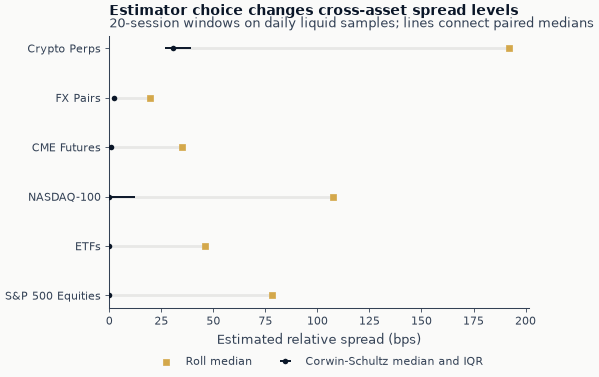

In [19]:
summary_pd = spread_summary.to_pandas()
y = np.arange(len(summary_pd))
fig, ax = plt.subplots(figsize=FIGSIZE["single_tall"])

for idx, row in summary_pd.iterrows():
    ax.hlines(
        y[idx],
        row["cs_median"],
        row["roll_median"],
        color=COLORS["silver_muted"],
        linewidth=2,
        zorder=1,
    )
    ax.errorbar(
        row["cs_median"],
        y[idx],
        xerr=[
            [max(row["cs_median"] - row["cs_p25"], 0)],
            [max(row["cs_p75"] - row["cs_median"], 0)],
        ],
        fmt="o",
        color=COLORS["blue"],
        capsize=3,
        label="Corwin-Schultz median and IQR" if idx == 0 else None,
        zorder=3,
    )
    ax.scatter(
        row["roll_median"],
        y[idx],
        marker="s",
        color=COLORS["amber"],
        label="Roll median" if idx == 0 else None,
        zorder=3,
    )

ax.set_yticks(y, summary_pd["asset_class"])
ax.set_xlim(left=0)
ax.set_xlabel("Estimated relative spread (bps)")
ax.set_ylabel("")
add_message_title(
    ax,
    "Estimator choice changes cross-asset spread levels",
    subtitle="20-session windows on daily liquid samples; lines connect paired medians",
)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.14), ncol=2)
fig.tight_layout()
fig.show()

## 5. Audit the Case-Study Cost Units

A spread estimate cannot be compared directly with a fee, an all-in cost, a tick count, or a
dollar-per-share half-spread. The nine configurations are therefore inventoried in native units.
No fallback converts an unknown schema into basis points.

In [20]:
case_studies = [
    "etfs",
    "crypto_perps_funding",
    "nasdaq100_microstructure",
    "sp500_equity_option_analytics",
    "us_firm_characteristics",
    "fx_pairs",
    "cme_futures",
    "sp500_options",
    "us_equities_panel",
]

schema_notes = {
    "etfs": ("USD/share commission + half-spread", "needs matched price conversion"),
    "crypto_perps_funding": ("maker/taker fee bps", "fee is not spread"),
    "nasdaq100_microstructure": (
        "USD/share commission + measured half-spread",
        "needs matched price and half/full convention",
    ),
    "sp500_equity_option_analytics": (
        "all-in per-leg bps range",
        "mixes spread, commission, and impact",
    ),
    "us_firm_characteristics": ("all-in per-leg bps range", "includes non-spread costs"),
    "fx_pairs": ("spread-bps ranges by pair class", "needs pair weights and convention"),
    "cme_futures": ("commission per contract + spread ticks", "needs product tick conversion"),
    "sp500_options": ("percent premium + hedge bps + fees", "uses multiple cost bases"),
    "us_equities_panel": ("all-in per-leg bps range", "includes non-spread costs"),
}

In [21]:
cost_rows = []
for case_study in case_studies:
    setup_path = get_case_study_source_dir(case_study) / "config" / "setup.yaml"
    if not setup_path.exists():
        raise FileNotFoundError(f"Missing required setup: {case_study}")
    costs = yaml.safe_load(setup_path.read_text()).get("costs", {})
    if not costs:
        raise ValueError(f"Missing costs configuration: {case_study}")
    native_unit, reason = schema_notes[case_study]
    cost_rows.append(
        {
            "case_study": case_study,
            "native_representation": native_unit,
            "direct_spread_bps_comparison": "No",
            "reason": reason,
        }
    )

cost_inventory = pl.DataFrame(cost_rows)
if len(cost_inventory) != len(case_studies):
    raise AssertionError("The cost-unit audit must cover all nine case studies.")
cost_inventory

case_study,native_representation,direct_spread_bps_comparison,reason
str,str,str,str
"""etfs""","""USD/share commission + half-sp…","""No""","""needs matched price conversion"""
"""crypto_perps_funding""","""maker/taker fee bps""","""No""","""fee is not spread"""
"""nasdaq100_microstructure""","""USD/share commission + measure…","""No""","""needs matched price and half/f…"
"""sp500_equity_option_analytics""","""all-in per-leg bps range""","""No""","""mixes spread, commission, and …"
"""us_firm_characteristics""","""all-in per-leg bps range""","""No""","""includes non-spread costs"""
"""fx_pairs""","""spread-bps ranges by pair clas…","""No""","""needs pair weights and convent…"
"""cme_futures""","""commission per contract + spre…","""No""","""needs product tick conversion"""
"""sp500_options""","""percent premium + hedge bps + …","""No""","""uses multiple cost bases"""
"""us_equities_panel""","""all-in per-leg bps range""","""No""","""includes non-spread costs"""


In [22]:
comparable_count = cost_inventory.filter(pl.col("direct_spread_bps_comparison") == "Yes").height
display(
    Markdown(
        f"**{len(cost_inventory)}/{len(case_studies)} configurations are present.** "
        f"Only **{comparable_count}** contain an asset-class-wide full-spread bps point estimate "
        "that is directly comparable with this notebook's OHLCV estimator sample. Treating the "
        "remaining fields as one spread number would fabricate a unit conversion."
    )
)

**9/9 configurations are present.** Only **0** contain an asset-class-wide full-spread bps point estimate that is directly comparable with this notebook's OHLCV estimator sample. Treating the remaining fields as one spread number would fabricate a unit conversion.

## 6. Retrospective VIX Conditioning

Full-history VIX quartiles create descriptive, retrospective regimes. Corwin-Schultz is itself a
high-low estimator, so association with VIX demonstrates estimator sensitivity to volatility. It
does not independently prove that quoted spreads or realized execution costs widened.

In [23]:
vix = (
    load_macro(series=["vixcls"])
    .select(
        pl.col("timestamp").cast(pl.Date),
        pl.col("vixcls").alias("vix"),
    )
    .filter(pl.col("vix").is_not_null())
    .sort("timestamp")
)
vix_q = tuple(vix["vix"].quantile(q) for q in (0.25, 0.50, 0.75))

etf_with_spreads = estimate_spreads(datasets["ETFs"]).filter(pl.col("cs_spread").is_not_null())
etf_vix = (
    etf_with_spreads.join(
        vix,
        left_on=pl.col("timestamp").cast(pl.Date),
        right_on="timestamp",
        how="inner",
    )
    .with_columns(cs_bps=pl.col("cs_spread") * 10_000)
    .with_columns(
        vix_regime=pl.when(pl.col("vix") < vix_q[0])
        .then(pl.lit("Q1 (Low)"))
        .when(pl.col("vix") < vix_q[1])
        .then(pl.lit("Q2"))
        .when(pl.col("vix") < vix_q[2])
        .then(pl.lit("Q3"))
        .otherwise(pl.lit("Q4 (High)"))
    )
)

In [24]:
regime_order = {"Q1 (Low)": 1, "Q2": 2, "Q3": 3, "Q4 (High)": 4}
regime_summary = (
    etf_vix.group_by("vix_regime")
    .agg(
        mean_bps=pl.col("cs_bps").mean(),
        median_bps=pl.col("cs_bps").median(),
        p90_bps=pl.col("cs_bps").quantile(0.90),
        observations=pl.len(),
    )
    .with_columns(order=pl.col("vix_regime").replace_strict(regime_order))
    .sort("order")
)

low_mean = regime_summary.filter(pl.col("vix_regime") == "Q1 (Low)")["mean_bps"].item()
high_mean = regime_summary.filter(pl.col("vix_regime") == "Q4 (High)")["mean_bps"].item()
display(
    Markdown(
        f"The full-sample VIX boundaries are **{vix_q[0]:.1f}**, **{vix_q[1]:.1f}**, and "
        f"**{vix_q[2]:.1f}**. Mean ETF Corwin-Schultz output moves from **{low_mean:.2f} bps** "
        f"in Q1 to **{high_mean:.2f} bps** in Q4. This is descriptive estimator sensitivity, "
        "not quote-based cost validation."
    )
)

The full-sample VIX boundaries are **13.9**, **17.7**, and **23.2**. Mean ETF Corwin-Schultz output moves from **0.69 bps** in Q1 to **1.55 bps** in Q4. This is descriptive estimator sensitivity, not quote-based cost validation.

### The Estimator's Right Tail Rises with VIX

Bars start at zero and show the regime mean. Labels carry the computed values without duplicating
them in static prose.

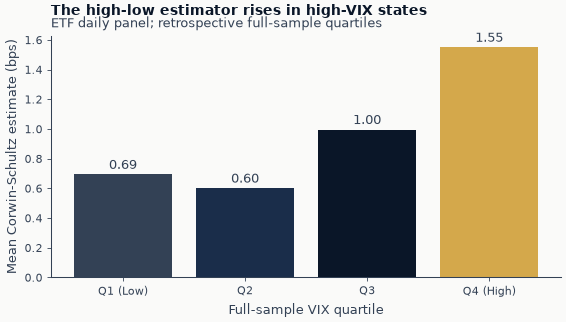

In [25]:
regime_pd = regime_summary.to_pandas()
fig, ax = plt.subplots(figsize=FIGSIZE["single"])
colors = [COLORS["neutral"], COLORS["slate"], COLORS["blue"], COLORS["amber"]]
bars = ax.bar(regime_pd["vix_regime"], regime_pd["mean_bps"], color=colors)
for bar, value in zip(bars, regime_pd["mean_bps"], strict=True):
    ax.annotate(
        f"{value:.2f}",
        xy=(bar.get_x() + bar.get_width() / 2, bar.get_height()),
        xytext=(0, 4),
        textcoords="offset points",
        ha="center",
        fontsize=9,
    )
ax.set_ylim(bottom=0)
ax.set_xlabel("Full-sample VIX quartile")
ax.set_ylabel("Mean Corwin-Schultz estimate (bps)")
add_message_title(
    ax,
    "The high-low estimator rises in high-VIX states",
    subtitle="ETF daily panel; retrospective full-sample quartiles",
)
fig.tight_layout()
fig.show()

### Keep VIX and Spread Estimates on Separate Axes

Aligned panels show timing without a dual-axis scale that could manufacture visual correlation.

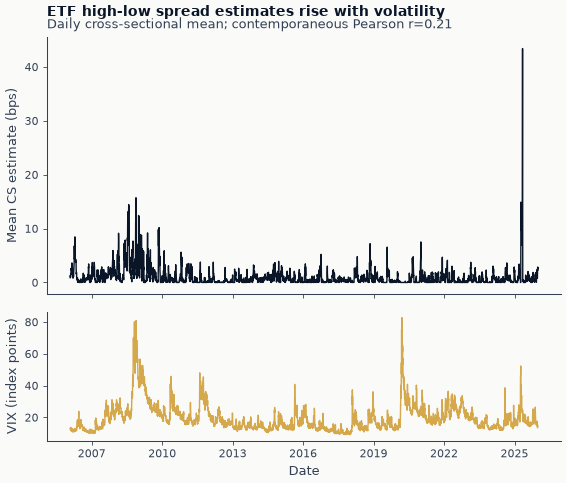

In [26]:
etf_ts = (
    etf_vix.group_by(pl.col("timestamp").cast(pl.Date).alias("timestamp"))
    .agg(mean_spread_bps=pl.col("cs_bps").mean())
    .sort("timestamp")
    .join(vix, on="timestamp", how="inner")
)
etf_ts_pd = etf_ts.to_pandas()
daily_association = etf_ts.select(pl.corr("mean_spread_bps", "vix")).item()

fig, (ax_spread, ax_vix) = plt.subplots(
    2,
    1,
    figsize=FIGSIZE["dual_v"],
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)
ax_spread.plot(
    etf_ts_pd["timestamp"],
    etf_ts_pd["mean_spread_bps"],
    color=COLORS["blue"],
    linewidth=1,
)
ax_spread.set_ylabel("Mean CS estimate (bps)")
add_message_title(
    ax_spread,
    "ETF high-low spread estimates rise with volatility",
    subtitle=f"Daily cross-sectional mean; contemporaneous Pearson r={daily_association:.2f}",
)

ax_vix.plot(etf_ts_pd["timestamp"], etf_ts_pd["vix"], color=COLORS["amber"], linewidth=1)
ax_vix.set_ylabel("VIX (index points)")
ax_vix.set_xlabel("Date")
ax_vix.xaxis.set_major_locator(mdates.YearLocator(3))
ax_vix.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.tight_layout()
fig.show()

## Key Takeaways

Exact findings below are generated from the current run so they remain synchronized when a reader
changes the sample or estimator window.

In [27]:
cs_lead = spread_summary.sort("cs_median", descending=True).row(0, named=True)
display(
    Markdown(
        "\n".join(
            [
                f"1. **Large-cap resolution is limited.** On {len(nq_estimated):,} matched "
                f"symbol-days, Corwin-Schultz bias is {cs_metrics['bias_bps']:+.1f} bps and "
                f"Roll bias is {roll_metrics['bias_bps']:+.1f} bps relative to the quoted-close "
                "benchmark.",
                f"2. **Cross-asset levels are estimator outputs, not observed costs.** "
                f"{cs_lead['asset_class']} has the largest median Corwin-Schultz output at "
                f"{cs_lead['cs_median']:.1f} bps in these liquid daily samples.",
                f"3. **VIX conditioning is descriptive.** The ETF estimator mean changes from "
                f"{low_mean:.2f} bps in Q1 to {high_mean:.2f} bps in Q4, while the method itself "
                "depends on high-low ranges.",
                f"4. **Cost units must remain explicit.** All {len(cost_inventory)} setup files "
                f"are present, and {comparable_count} provide a directly comparable full-spread "
                "bps point estimate for the same sample.",
                "\n**Next:** `03_market_impact_calibration` estimates the separate market-impact "
                "component. Chapter 18.3 explains why any cost parameter must be conditioned on "
                "market state.",
            ]
        )
    )
)

1. **Large-cap resolution is limited.** On 516 matched symbol-days, Corwin-Schultz bias is +7.6 bps and Roll bias is +115.6 bps relative to the quoted-close benchmark.
2. **Cross-asset levels are estimator outputs, not observed costs.** Crypto Perps has the largest median Corwin-Schultz output at 30.6 bps in these liquid daily samples.
3. **VIX conditioning is descriptive.** The ETF estimator mean changes from 0.69 bps in Q1 to 1.55 bps in Q4, while the method itself depends on high-low ranges.
4. **Cost units must remain explicit.** All 9 setup files are present, and 0 provide a directly comparable full-spread bps point estimate for the same sample.

**Next:** `03_market_impact_calibration` estimates the separate market-impact component. Chapter 18.3 explains why any cost parameter must be conditioned on market state.